# Declaration of Originality

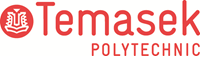

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Joshua (2400591J)
* Tutorial Group                :  TC03
* Tutor						    :  Ruchir Srivastava
* Submission Date               : 11/2/2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Business Understanding
Goal: to predict fitness class of different people

# 2. Data Understanding

## 2.1 Load dataset

In [8]:
df = pd.read_csv("bodyPerformance.csv")

df.columns = df.columns.str.strip()           # Remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_") # Replace spaces with underscores
df.columns = df.columns.str.lower()           # Lowercase all column names

print("Columns after cleaning:")

Columns after cleaning:


## 2.2 Summary Statistics

In [9]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body_fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripforce                13393 non-null  float64
 8   sit_and_bend_forward_cm  13393 non-null  float64
 9   sit-ups_counts           13393 non-null  float64
 10  broad_jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [10]:
## Check for missing data
df.isna().sum()

age                        0
gender                     0
height_cm                  0
weight_kg                  0
body_fat_%                 0
diastolic                  0
systolic                   0
gripforce                  0
sit_and_bend_forward_cm    0
sit-ups_counts             0
broad_jump_cm              0
class                      0
dtype: int64

In [11]:
# Describe numerical features
print("\nSummary statistics for numerical columns:")
print(df.describe())

# Describe categorical columns
print("\nSummary statistics for categorical columns:")
print(df.describe(include=['object']))



Summary statistics for numerical columns:
                age     height_cm     weight_kg    body_fat_%     diastolic  \
count  13393.000000  13393.000000  13393.000000  13393.000000  13393.000000   
mean      36.775106    168.559807     67.447316     23.240165     78.796842   
std       13.625639      8.426583     11.949666      7.256844     10.742033   
min       21.000000    125.000000     26.300000      3.000000      0.000000   
25%       25.000000    162.400000     58.200000     18.000000     71.000000   
50%       32.000000    169.200000     67.400000     22.800000     79.000000   
75%       48.000000    174.800000     75.300000     28.000000     86.000000   
max       64.000000    193.800000    138.100000     78.400000    156.200000   

           systolic     gripforce  sit_and_bend_forward_cm  sit-ups_counts  \
count  13393.000000  13393.000000             13393.000000    13393.000000   
mean     130.234817     36.963877                15.209268       39.771224   
std       1

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

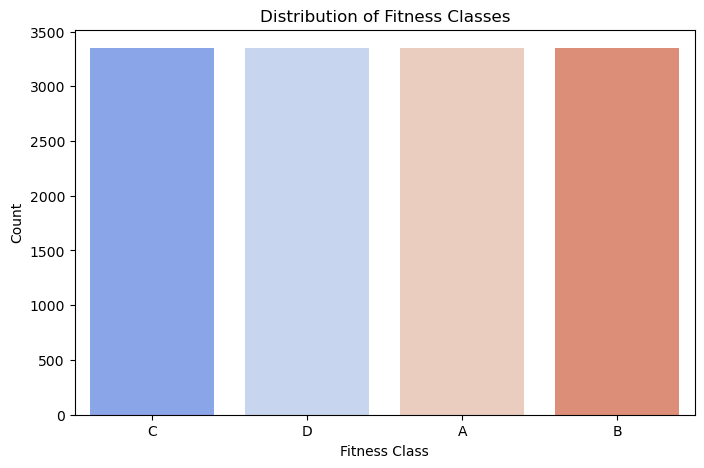

In [22]:
target_col = "class"

plt.figure(figsize=(8,5))
sns.countplot(data=df, x=target_col, palette='coolwarm', order=df[target_col].value_counts().index)
plt.title('Distribution of Fitness Classes')
plt.xlabel('Fitness Class')
plt.ylabel('Count')
plt.show()


### 2.3.1.2 Understanding distribution of features

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


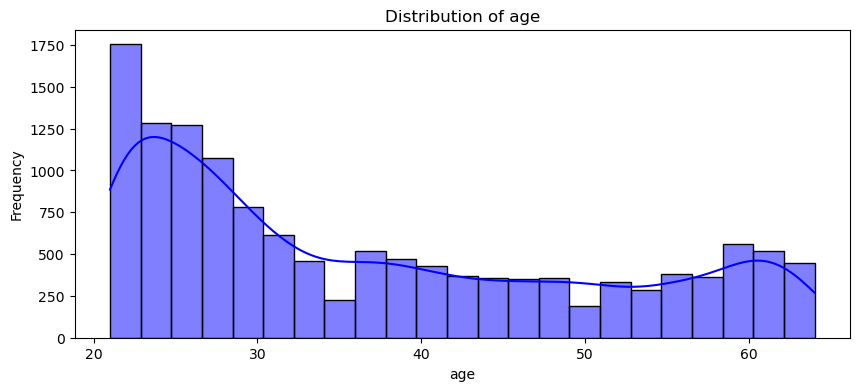

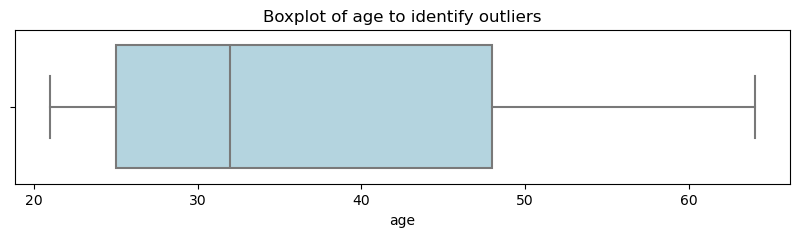

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


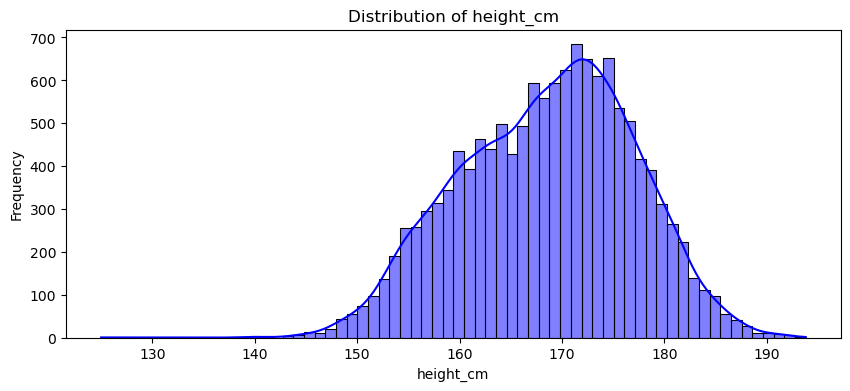

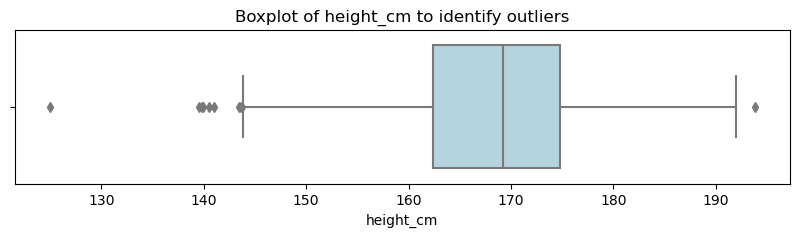

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


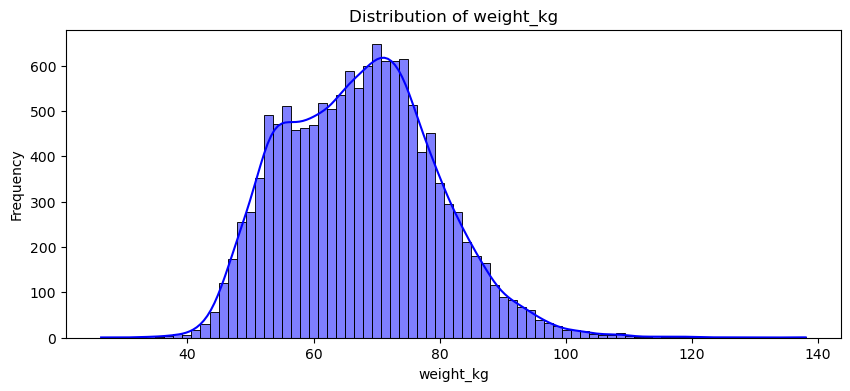

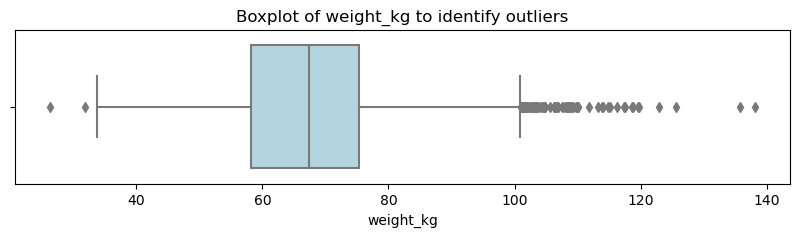

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


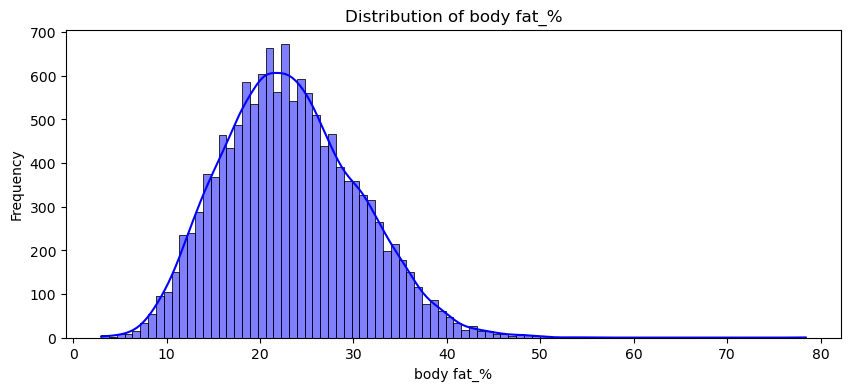

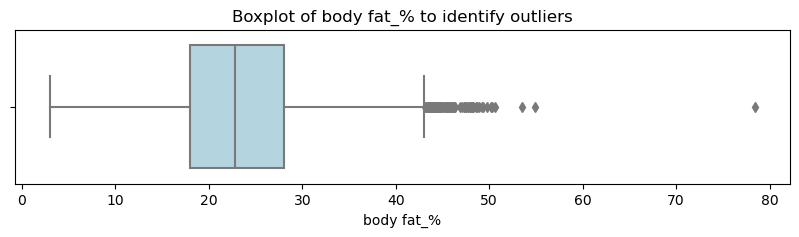

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


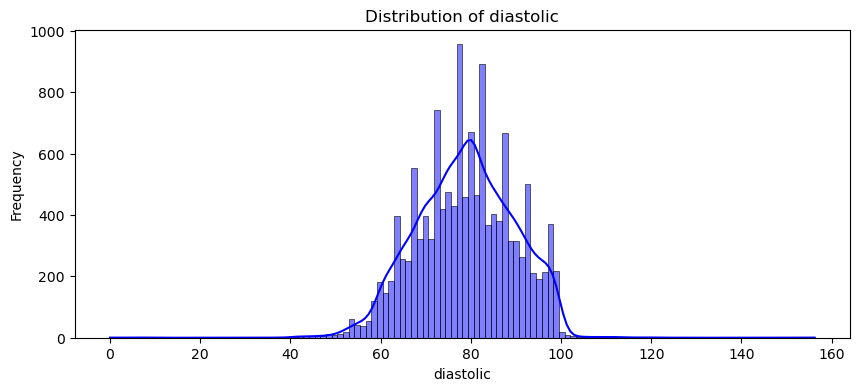

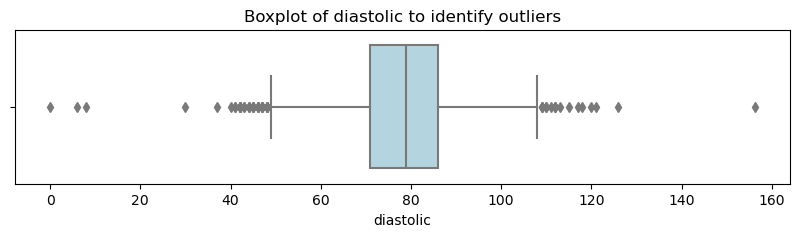

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


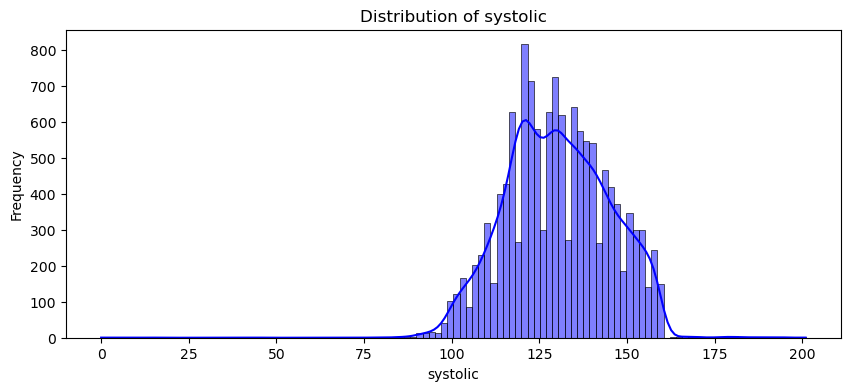

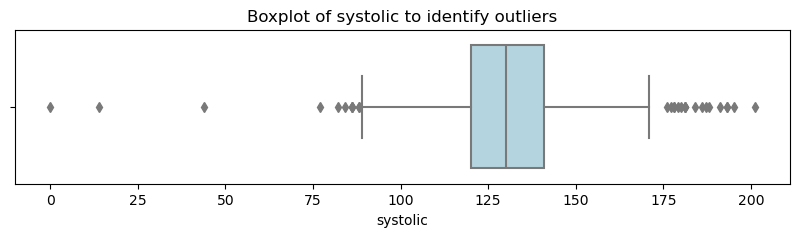

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


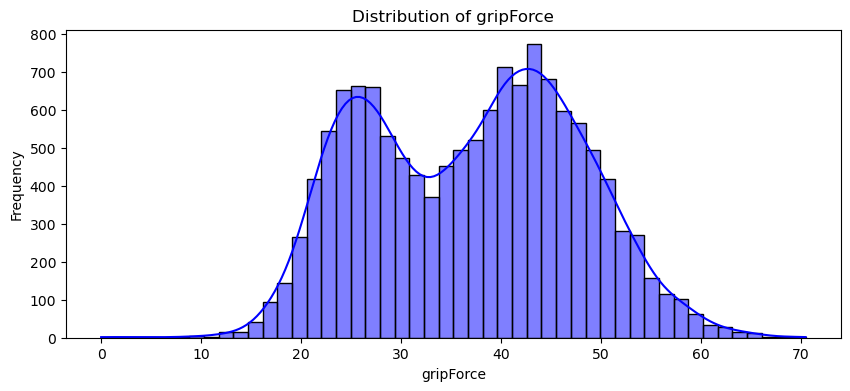

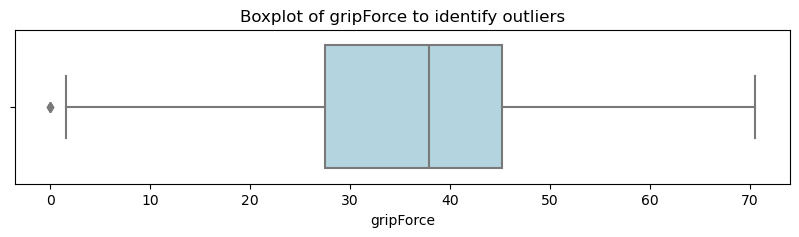

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


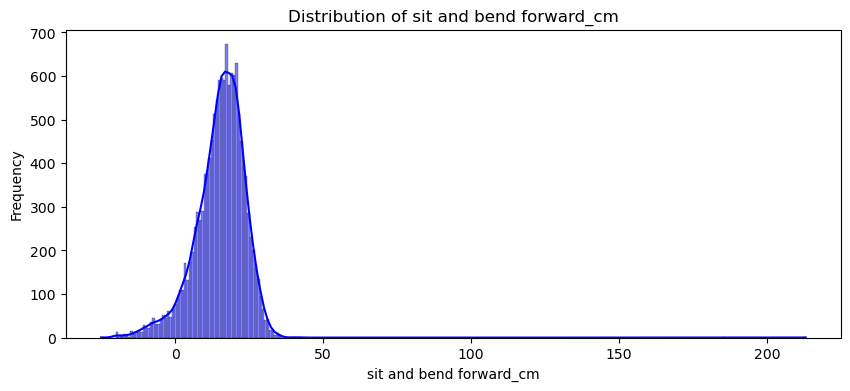

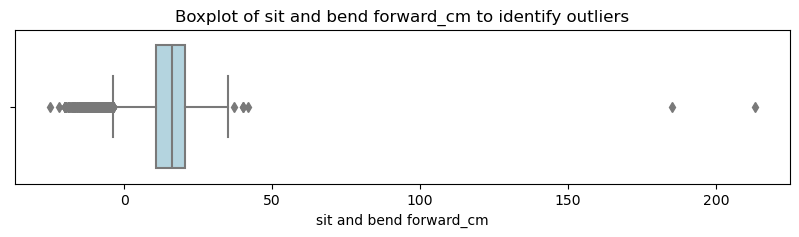

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


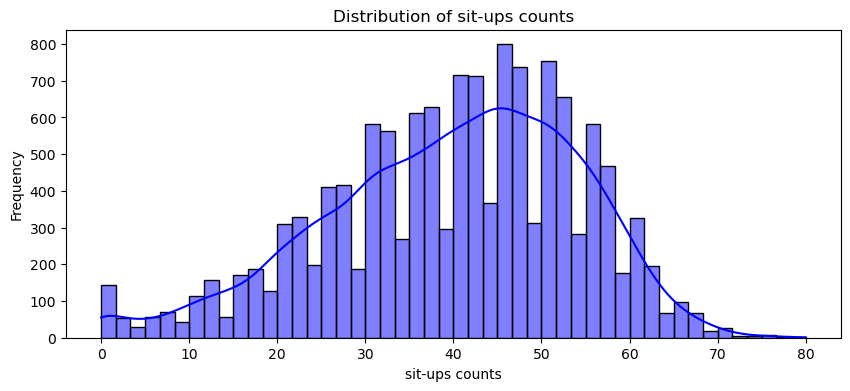

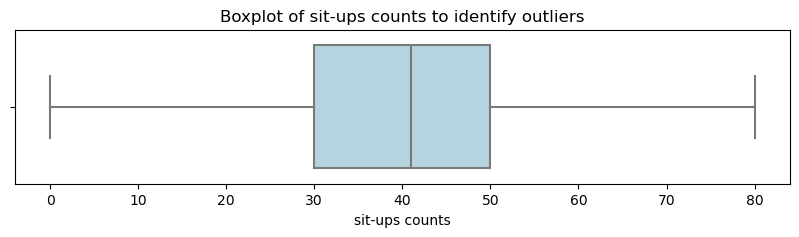

c:\Users\samjs\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


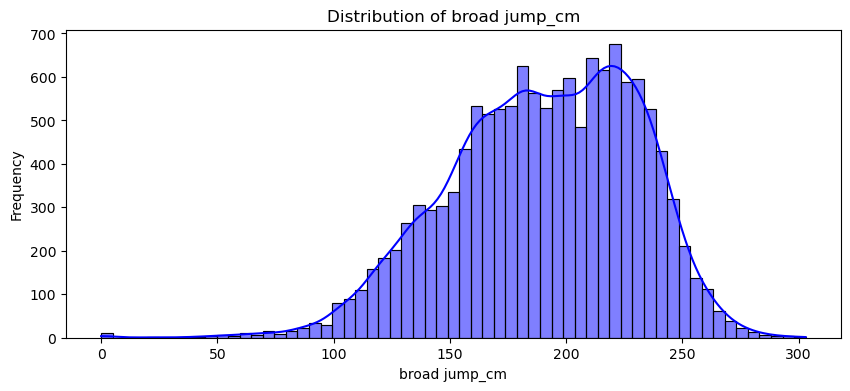

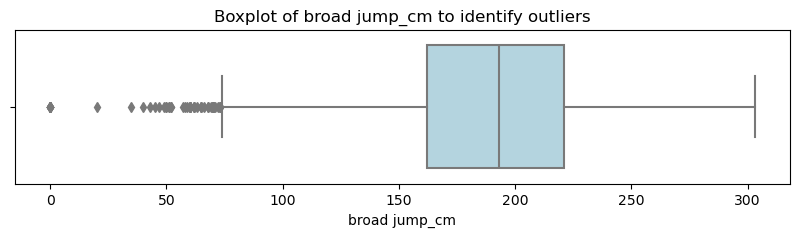

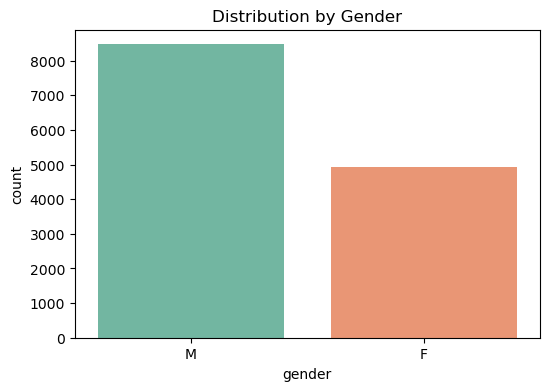

In [23]:
# 4. Features distribution
# =============================
# Numeric Features
num_features = [
    "age", "height_cm", "weight_kg", "body fat_%", 
    "diastolic", "systolic", "gripForce",
    "sit and bend forward_cm", "sit-ups counts", "broad jump_cm"
]

for col in num_features:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col].dropna(), kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(10,2))
    sns.boxplot(x=df[col].dropna(), color='lightblue')
    plt.title(f'Boxplot of {col} to identify outliers')
    plt.xlabel(col)
    plt.show()

# Categorical Features
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender", palette='Set2')
plt.title('Distribution by Gender')
plt.show()

### 2.3.2 Understanding relationship between variables

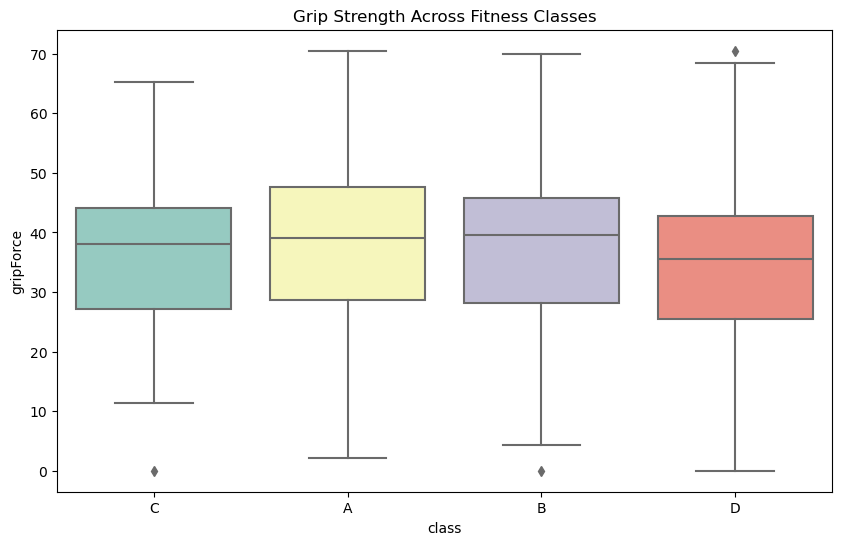

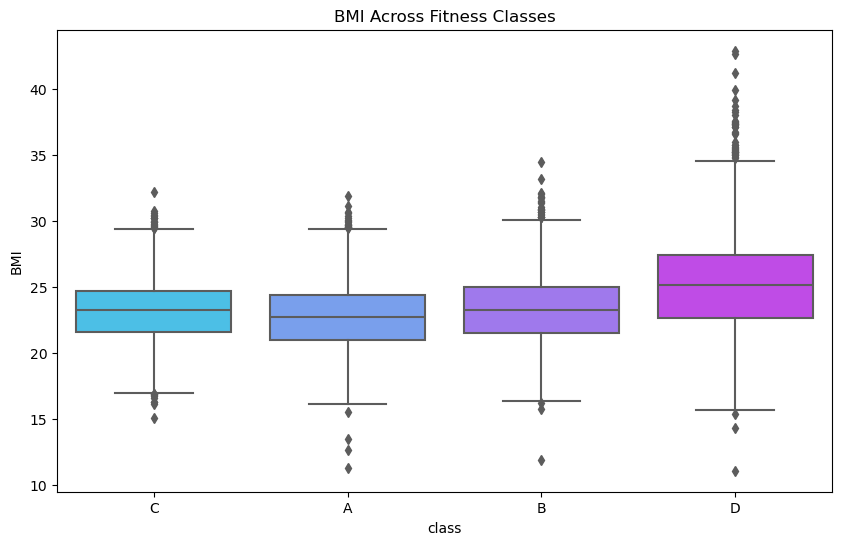

In [24]:
# 5. Relationship between variables
# =============================
# Example: GripForce vs Fitness Class
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x=target_col, y='gripForce', palette='Set3')
plt.title('Grip Strength Across Fitness Classes')
plt.show()

# Example: BMI vs Fitness Class
df["BMI"] = df["weight_kg"] / ((df["height_cm"]/100)**2)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x=target_col, y='BMI', palette='cool')
plt.title('BMI Across Fitness Classes')
plt.show()


# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
num_cols = [
    "age", "height_cm", "weight_kg", "body_fat_%", 
    "diastolic", "systolic", "gripforce",
    "sit_and_bend_forward_cm", "sit-ups_counts", "broad_jump_cm"
]

# Convert to numeric and fill missing values with median
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

# Encode target if needed
df['class'] = df['class'].astype(str)

# Check for any remaining NaNs
print("\n✅ Missing values after cleaning:")
print(df.isna().sum())

# =============================
# 4. Feature Selection
# =============================
features = num_cols + ["gender"]  # Keep gender as categorical
X = df[features].copy()
y = df["class"]

# Encode gender (Female:0, Male:1)
X = pd.get_dummies(X, columns=["gender"], drop_first=True)

# =============================
# 5. Feature Engineering
# =============================
X["bmi"] = X["weight_kg"] / ((X["height_cm"]/100)**2)
X["bp_ratio"] = X["systolic"] / (X["diastolic"] + 0.1)
X["age_grip"] = X["age"] * X["gripforce"]
X["weight_height_ratio"] = X["weight_kg"] / X["height_cm"]
X["strength_weight"] = X["gripforce"] / X["weight_kg"]
X["bodyfat_bmi"] = X["body_fat_%"] * X["bmi"]


✅ Missing values after cleaning:
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body_fat_%                 0
diastolic                  0
systolic                   0
gripforce                  0
sit_and_bend_forward_cm    0
sit-ups_counts             0
broad_jump_cm              0
class                      0
dtype: int64


## 3.2 Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape}, Test size: {X_test.shape}")


✅ Train size: (10714, 17), Test size: (2679, 17)


# 4. Modelling

### 4.2 Train Model

In [14]:
# 6. Train Initial Model
# =============================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

# 5. Model Evaluation


Accuracy Score:
0.7252706233669279

Classification Report:
              precision    recall  f1-score   support

           A       0.70      0.85      0.77       670
           B       0.62      0.54      0.57       669
           C       0.69      0.70      0.69       670
           D       0.91      0.82      0.86       670

    accuracy                           0.73      2679
   macro avg       0.73      0.73      0.72      2679
weighted avg       0.73      0.73      0.72      2679



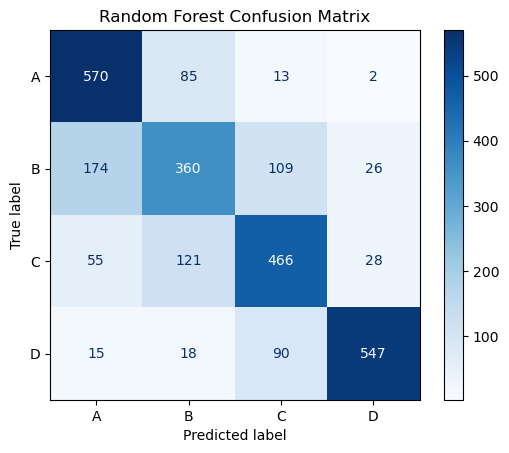

In [15]:
# =============================
# 7. Model Evaluation
# =============================
y_pred = model.predict(X_test)

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [17]:
# Smaller search space (still 3 values each for rubric)
param_distributions = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 8]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_distributions=param_distributions,
    n_iter=3,          # 🔥 reduce from 5 to 3 (much faster)
    cv=3,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

best_model = rf_random.best_estimator_
tuned_preds = best_model.predict(X_test)

print("✅ Best Parameters:", rf_random.best_params_)
print("✅ Accuracy:", accuracy_score(y_test, tuned_preds))
print(classification_report(y_test, tuned_preds))

✅ Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': 15}
✅ Accuracy: 0.748040313549832
              precision    recall  f1-score   support

           A       0.74      0.86      0.79       670
           B       0.63      0.59      0.61       669
           C       0.73      0.70      0.71       670
           D       0.90      0.84      0.87       670

    accuracy                           0.75      2679
   macro avg       0.75      0.75      0.75      2679
weighted avg       0.75      0.75      0.75      2679



## Iterative model development


In [20]:
# =============================
# Iteration 2: Add More Features
# =============================

X_full = df[[
    'age', 'height_cm', 'weight_kg', 'body_fat_%',
    'diastolic', 'systolic', 'gripforce',
    'sit_and_bend_forward_cm', 'sit-ups_counts', 'broad_jump_cm',
    'gender'
]]

# One-hot encode gender
X_full = pd.get_dummies(X_full, columns=['gender'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain model
rf_model2 = RandomForestClassifier(random_state=42)
rf_model2.fit(X_train, y_train)

# Evaluate
model2_preds = rf_model2.predict(X_test)
model2_acc = accuracy_score(y_test, model2_preds)

print(f"Improved Accuracy (More Features): {model2_acc:.4f}")



Improved Accuracy (More Features): 0.7469


In [21]:
bundle = {
    "model": model,
    "columns": list(X.columns)
}

joblib.dump(bundle, "fitness_classifier.pkl", compress=3)

print("✅ fitness_classifier.pkl saved successfully!")

✅ fitness_classifier.pkl saved successfully!
